In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/pipeline_runs.csv')


In [3]:
df.head()

,pipeline_name,input_records,output_records,data_size_mb,execution_time_min,expected_time_min,cpu_utilization,memory_utilization,source_delay_min,retry_count,previous_run_duration,previous_failure_count,worker_count,day_of_week,hour,pipeline_failed
0,customer_daily,568009,548074,997.9,15.50,25,21.1,33.9,1.4,1,12.99,0,4,Friday,4,0
1,sales_daily,1142449,1102039,2417.2,37.47,30,76.0,99.0,12.6,0,34.11,0,6,Friday,5,0
2,products_daily,399940,407443,723.2,17.85,18,53.5,50.3,13.1,1,15.87,0,4,Thursday,5,0
3,payments_daily,401165,403770,774.5,28.19,32,37.9,56.4,1.3,0,26.26,0,6,Tuesday,6,0
4,orders_daily,838246,845167,1210.7,22.23,28,24.1,45.3,5.6,1,21.48,0,8,Saturday,2,0


In [4]:
# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 30000
Number of columns: 16


In [5]:
# Display column names
print("Column Names:")
for column in df.columns:
    print(column)

Column Names:
pipeline_name
input_records
output_records
data_size_mb
execution_time_min
expected_time_min
cpu_utilization
memory_utilization
source_delay_min
retry_count
previous_run_duration
previous_failure_count
worker_count
day_of_week
hour
pipeline_failed


In [6]:
# Display complete dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pipeline_name           30000 non-null  object 
 1   input_records           30000 non-null  int64  
 2   output_records          30000 non-null  int64  
 3   data_size_mb            30000 non-null  float64
 4   execution_time_min      30000 non-null  float64
 5   expected_time_min       30000 non-null  int64  
 6   cpu_utilization         30000 non-null  float64
 7   memory_utilization      29700 non-null  float64
 8   source_delay_min        29700 non-null  float64
 9   retry_count             30000 non-null  int64  
 10  previous_run_duration   29700 non-null  float64
 11  previous_failure_count  30000 non-null  int64  
 12  worker_count            30000 non-null  int64  
 13  day_of_week             30000 non-null  object 
 14  hour                    30000 non-null

In [7]:
# Statistical summary of numerical columns
df.describe()

,input_records,output_records,data_size_mb,execution_time_min,expected_time_min,cpu_utilization,memory_utilization,source_delay_min,retry_count,previous_run_duration,previous_failure_count,worker_count,hour,pipeline_failed
count,3.000000e+04,3.000000e+04,30000.000000,30000.000000,30000.00000,30000.00000,29700.000000,29700.000000,30000.000000,29700.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,6.300606e+05,6.302050e+05,1158.715917,26.684347,26.14590,46.54443,61.205145,6.013707,0.489567,24.533296,0.120533,4.497200,8.486433,0.034733
std,2.550285e+05,2.555117e+05,493.883433,7.059724,4.38241,17.16803,18.902597,4.975891,0.875966,7.279434,0.347288,1.765851,6.587503,0.183107
min,5.000000e+04,4.870100e+04,100.000000,8.830000,18.00000,15.00000,20.000000,0.000000,0.000000,6.950000,0.000000,2.000000,0.000000,0.000000
25%,4.044368e+05,4.051630e+05,747.700000,21.560000,22.00000,34.20000,47.500000,2.400000,0.000000,19.220000,0.000000,4.000000,3.000000,0.000000
50%,6.227225e+05,6.222085e+05,1130.650000,26.140000,28.00000,45.40000,60.700000,4.700000,0.000000,23.770000,0.000000,4.000000,6.000000,0.000000
75%,8.222008e+05,8.219412e+05,1507.725000,31.140000,30.00000,57.60000,74.500000,8.200000,1.000000,28.900000,0.000000,6.000000,14.000000,0.000000
max,1.574168e+06,1.532493e+06,3139.400000,65.970000,32.00000,99.00000,99.000000,46.200000,4.000000,65.400000,4.000000,8.000000,23.000000,1.000000


Check data types

In [8]:
data_types = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

data_types

,Column,Data Type,Unique Values
0,pipeline_name,object,6
1,input_records,int64,29521
2,output_records,int64,29513
3,data_size_mb,float64,14884
4,execution_time_min,float64,3518
5,expected_time_min,int64,6
6,cpu_utilization,float64,834
7,memory_utilization,float64,791
8,source_delay_min,float64,347
9,retry_count,int64,5


In [9]:
# Count missing values
missing_values = df.isnull().sum()

missing_values

,0
pipeline_name,0
input_records,0
output_records,0
data_size_mb,0
execution_time_min,0
expected_time_min,0
cpu_utilization,0
memory_utilization,300
source_delay_min,300
retry_count,0


In [10]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
# Target distribution
target_counts = df['pipeline_failed'].value_counts()

print(target_counts)

pipeline_failed
0    28958
1     1042
Name: count, dtype: int64


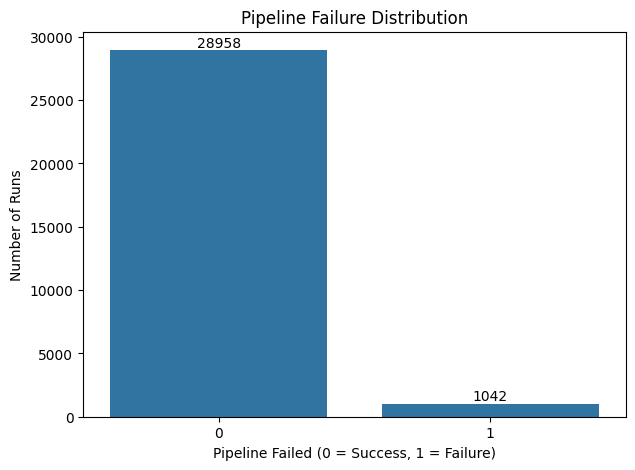

In [12]:
target_percentage = df['pipeline_failed'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='pipeline_failed'
)

plt.title('Pipeline Failure Distribution')
plt.xlabel('Pipeline Failed (0 = Success, 1 = Failure)')
plt.ylabel('Number of Runs')

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [13]:
failure_rate = df['pipeline_failed'].mean() * 100

print(f"Overall Pipeline Failure Rate: {failure_rate:.2f}%")

Overall Pipeline Failure Rate: 3.47%


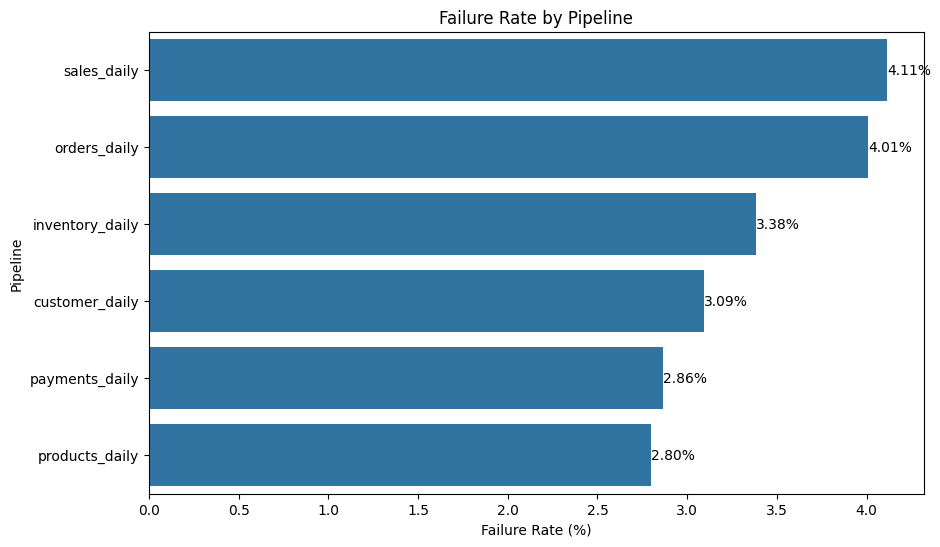



The pipeline with the highest observed failure rate is 'sales_daily' with a failure rate of 4.11%.


In [14]:
# Calculate failure rate for each pipeline
failure_by_pipeline = (
    df.groupby('pipeline_name')['pipeline_failed']
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=failure_by_pipeline.values,
    y=failure_by_pipeline.index
)

plt.title('Failure Rate by Pipeline')
plt.xlabel('Failure Rate (%)')
plt.ylabel('Pipeline')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.show()

print("\n")

highest_failure_pipeline = failure_by_pipeline.index[0]
highest_failure_rate = failure_by_pipeline.iloc[0]

print(
    f"The pipeline with the highest observed failure rate is "
    f"'{highest_failure_pipeline}' with a failure rate of "
    f"{highest_failure_rate:.2f}%."
)

**Data Preprocessing**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [16]:
# Separate features and target
X = df.drop('pipeline_failed', axis=1)
y = df['pipeline_failed']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30000, 15)
Target shape: (30000,)


In [17]:
# Identify numerical columns
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Identify categorical columns
categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

Numerical Features:
['input_records', 'output_records', 'data_size_mb', 'execution_time_min', 'expected_time_min', 'cpu_utilization', 'memory_utilization', 'source_delay_min', 'retry_count', 'previous_run_duration', 'previous_failure_count', 'worker_count', 'hour']

Number of numerical features: 13

Categorical Features:
['pipeline_name', 'day_of_week']

Number of categorical features: 2


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training and testing datasets created.")

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_test :", y_test.shape)

Training and testing datasets created.

X_train: (24000, 15)
X_test : (6000, 15)

y_train: (24000,)
y_test : (6000,)


In [19]:
print("Original Dataset:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining Dataset:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Dataset:")
print(y_test.value_counts(normalize=True) * 100)

Original Dataset:
pipeline_failed
0    96.526667
1     3.473333
Name: proportion, dtype: float64

Training Dataset:
pipeline_failed
0    96.525
1     3.475
Name: proportion, dtype: float64

Testing Dataset:
pipeline_failed
0    96.533333
1     3.466667
Name: proportion, dtype: float64


Stratified Train-Test Split:
Since the target variable is imbalanced, stratification was used to preserve approximately the same proportion of successful and failed pipeline runs in both the training and testing datasets.

In [20]:
# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [21]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [22]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numerical_pipeline,
            numerical_features
        ),
        (
            'cat',
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Complete preprocessing pipeline created.")

Complete preprocessing pipeline created.


In [23]:
# Fit preprocessing pipeline ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-fitted preprocessor to test data
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")

print("\nX_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

Preprocessing completed successfully!

X_train_processed shape: (24000, 26)
X_test_processed shape : (6000, 26)


In [24]:
print(
    "Any NaN in X_train_processed:",
    np.isnan(X_train_processed).any()
)

print(
    "Any NaN in X_test_processed:",
    np.isnan(X_test_processed).any()
)

Any NaN in X_train_processed: False
Any NaN in X_test_processed: False


In [25]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))


Number of processed features: 26


In [26]:
# Convert processed arrays into DataFrames

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training data:")
display(X_train_processed_df.head())

Processed training data:


,num__input_records,num__output_records,num__data_size_mb,num__execution_time_min,num__expected_time_min,num__cpu_utilization,num__memory_utilization,num__source_delay_min,num__retry_count,num__previous_run_duration,...,cat__pipeline_name_payments_daily,cat__pipeline_name_products_daily,cat__pipeline_name_sales_daily,cat__day_of_week_Friday,cat__day_of_week_Monday,cat__day_of_week_Saturday,cat__day_of_week_Sunday,cat__day_of_week_Thursday,cat__day_of_week_Tuesday,cat__day_of_week_Wednesday
232,-1.249641,-1.244300,-1.160188,1.124268,1.335127,0.135771,-1.856918,0.242237,-0.559973,0.994400,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
27019,0.746703,0.650697,1.083938,0.348925,0.879556,-0.535492,1.719331,-0.949736,0.576355,0.633815,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
14172,-1.548174,-1.590535,-1.279794,-1.785749,-1.853870,-0.809834,-1.468427,-0.101213,-0.559973,-1.586336,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
26403,0.065639,0.087081,-0.300041,0.300732,-0.259372,0.812871,-0.271022,-0.788113,-0.559973,0.049419,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22672,-0.556731,-0.574249,-0.732446,-0.684393,-0.942728,-0.868205,-0.574365,-0.586084,0.576355,-0.554318,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
# Check processed dataset information

print("Processed Training Dataset")
print("--------------------------------")
print("Rows:", X_train_processed_df.shape[0])
print("Columns:", X_train_processed_df.shape[1])

print("\nProcessed Testing Dataset")
print("--------------------------------")
print("Rows:", X_test_processed_df.shape[0])
print("Columns:", X_test_processed_df.shape[1])

Processed Training Dataset
--------------------------------
Rows: 24000
Columns: 26

Processed Testing Dataset
--------------------------------
Rows: 6000
Columns: 26


Final Preprocessing summary

In [28]:
print("=" * 60)
print("             PREPROCESSING SUMMARY")
print("=" * 60)

print(f"\nOriginal dataset:        {df.shape}")

print(f"Training features:       {X_train.shape}")
print(f"Testing features:        {X_test.shape}")

print(f"\nProcessed training data: {X_train_processed.shape}")
print(f"Processed testing data:  {X_test_processed.shape}")

print(f"\nOriginal features:       {X.shape[1]}")
print(f"Processed features:      {X_train_processed.shape[1]}")

print("\nNumerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print(
    "\nMissing values after preprocessing:"
)
print(
    "Training:",
    np.isnan(X_train_processed).sum()
)
print(
    "Testing :",
    np.isnan(X_test_processed).sum()
)

print("\n" + "=" * 60)

             PREPROCESSING SUMMARY

Original dataset:        (30000, 16)
Training features:       (24000, 15)
Testing features:        (6000, 15)

Processed training data: (24000, 26)
Processed testing data:  (6000, 26)

Original features:       15
Processed features:      26

Numerical features: 13
Categorical features: 2

Missing values after preprocessing:
Training: 0
Testing : 0



In [29]:
import joblib

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    '/content/preprocessor.pkl'
)

print("Preprocessing pipeline saved successfully!")

Preprocessing pipeline saved successfully!


## Model Building

Now that the preprocessing pipeline is ready, we train and compare three classifiers of increasing complexity:

1. **Logistic Regression** — simple, interpretable baseline
2. **Random Forest** — non-linear, handles feature interactions
3. **XGBoost** — gradient boosting, usually the strongest tabular performer

**Note on class imbalance:** only ~3.47% of runs failed. A model that always predicts "success" would already be ~96.5% accurate but completely useless — it would catch zero failures. So every model below is trained to account for the imbalance (`class_weight='balanced'` / `scale_pos_weight`), and we judge them primarily on **Recall, F1, ROC-AUC and PR-AUC** rather than accuracy.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    f1_score
)

In [31]:
# Reusable evaluation function so every model is scored the same way

results = {}          # stores metrics for the comparison table later
roc_curves = {}        # stores (fpr, tpr) for the combined ROC plot
pr_curves = {}          # stores (precision, recall) for the combined PR plot

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("=" * 60)
    print(f"{name} — Evaluation")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=['Success', 'Failure']))

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Success', 'Failure'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{name} — Confusion Matrix')
    plt.show()

    # Store for later comparison
    results[name] = {
        'Precision': classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        'Recall': classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves[name] = (fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_curves[name] = (precision, recall)

    return y_pred, y_proba

### 1. Logistic Regression (Baseline)

In [32]:
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_processed, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


Logistic Regression — Evaluation
              precision    recall  f1-score   support

     Success       0.99      0.75      0.85      5792
     Failure       0.09      0.72      0.16       208

    accuracy                           0.75      6000
   macro avg       0.54      0.73      0.51      6000
weighted avg       0.96      0.75      0.83      6000

ROC-AUC : 0.7922
PR-AUC  : 0.2050


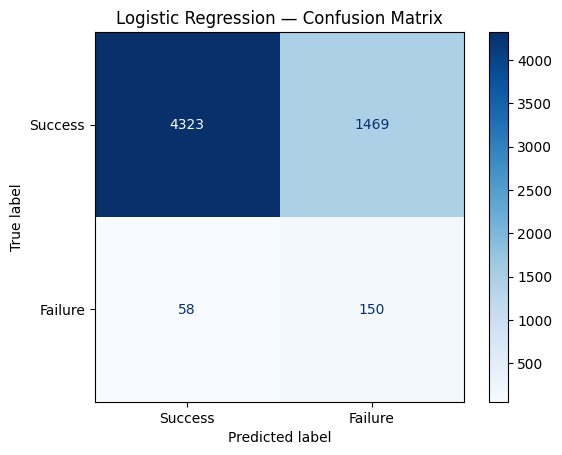

In [33]:
lr_pred, lr_proba = evaluate_model('Logistic Regression', log_reg, X_test_processed, y_test)

### 2. Random Forest

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained.")

Random Forest trained.


Random Forest — Evaluation
              precision    recall  f1-score   support

     Success       0.97      1.00      0.98      5792
     Failure       0.00      0.00      0.00       208

    accuracy                           0.97      6000
   macro avg       0.48      0.50      0.49      6000
weighted avg       0.93      0.97      0.95      6000

ROC-AUC : 0.7567
PR-AUC  : 0.1525


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


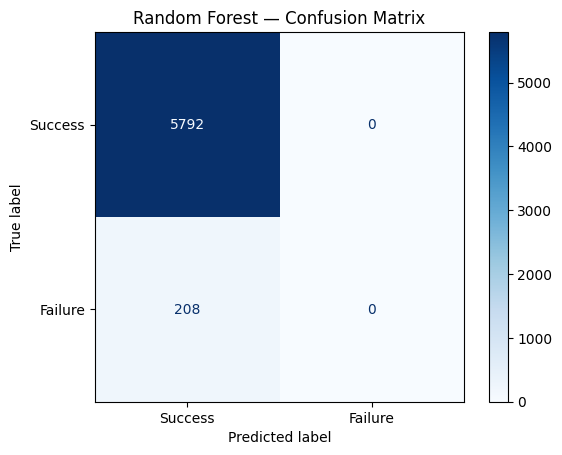

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [35]:
rf_pred, rf_proba = evaluate_model('Random Forest', rf_model, X_test_processed, y_test)

### 3. XGBoost

In [36]:
# scale_pos_weight tells XGBoost how much to up-weight the minority (failure) class
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print(f"scale_pos_weight (neg/pos): {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost trained.")

scale_pos_weight (neg/pos): 27.78
XGBoost trained.


XGBoost — Evaluation
              precision    recall  f1-score   support

     Success       0.98      0.90      0.93      5792
     Failure       0.13      0.42      0.20       208

    accuracy                           0.88      6000
   macro avg       0.55      0.66      0.56      6000
weighted avg       0.95      0.88      0.91      6000

ROC-AUC : 0.7361
PR-AUC  : 0.1610


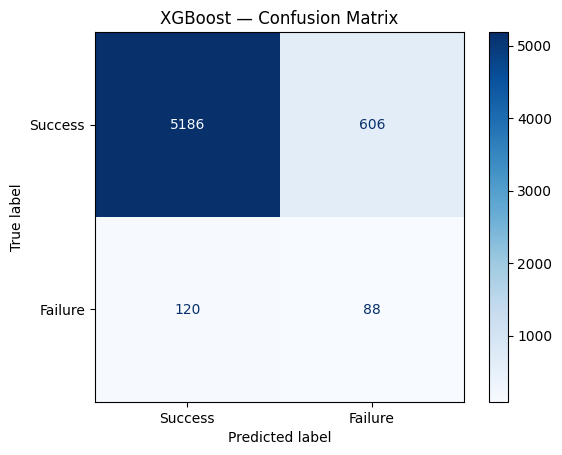

In [37]:
xgb_pred, xgb_proba = evaluate_model('XGBoost', xgb_model, X_test_processed, y_test)

## Model Comparison

Accuracy is left out on purpose — with a ~96.5%/3.5% split it would flatter every model equally and hide the difference that actually matters: how many real failures each model catches (Recall) without drowning engineers in false alarms (Precision).

Model Comparison (sorted by F1-Score)


,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
XGBoost,0.1268,0.4231,0.1951,0.7361,0.1610
Logistic Regression,0.0926,0.7212,0.1642,0.7922,0.2050
Random Forest,0.0000,0.0000,0.0000,0.7567,0.1525


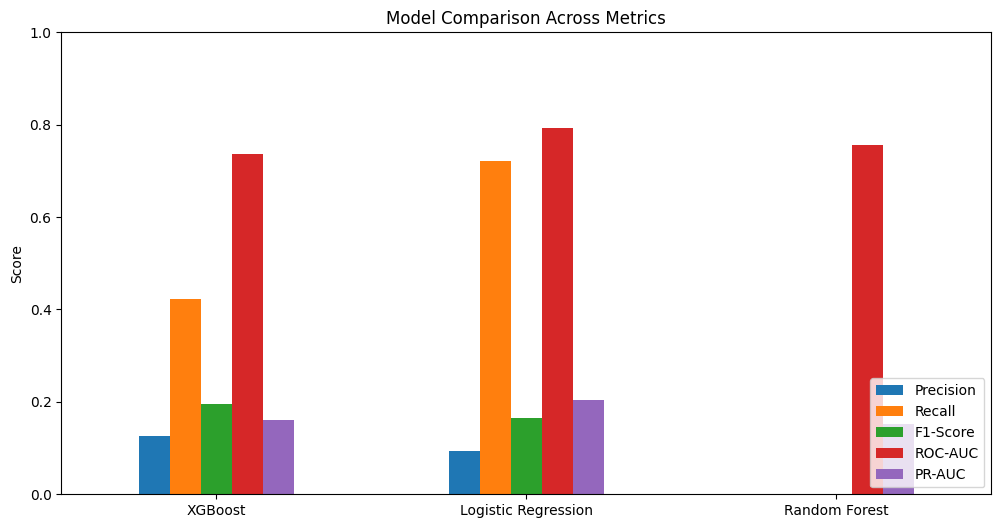

In [38]:
comparison_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
comparison_df = comparison_df.round(4)

print("Model Comparison (sorted by F1-Score)")
print("=" * 60)
display(comparison_df)

comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.show()

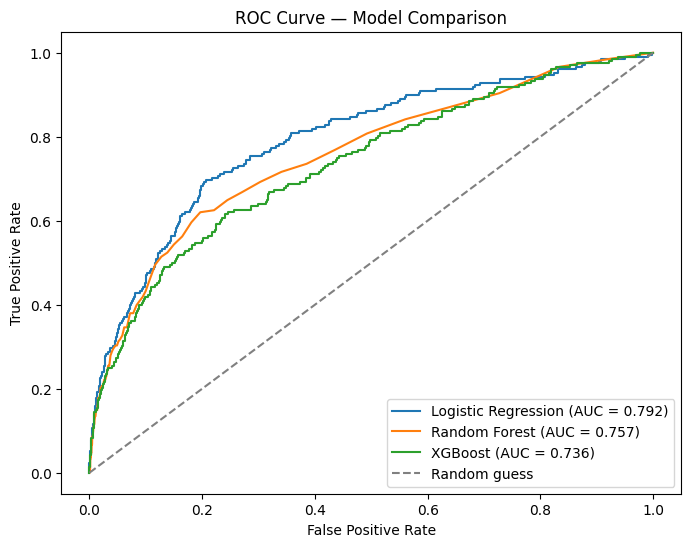

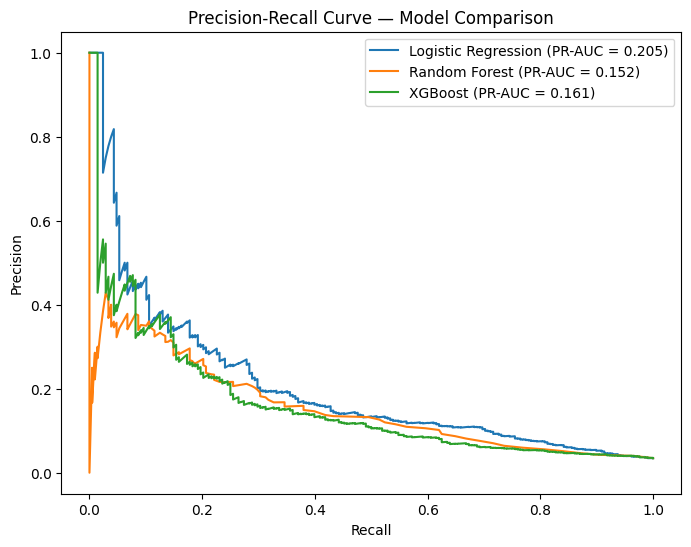

In [39]:
# Combined ROC curve
plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.show()

# Combined Precision-Recall curve — more informative than ROC on an imbalanced target
plt.figure(figsize=(8, 6))
for name, (precision, recall) in pr_curves.items():
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {results[name]['PR-AUC']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Model Comparison')
plt.legend()
plt.show()

**Choosing the "best" model:** pick whichever model wins on F1 / PR-AUC, not just accuracy. In the cells below, `best_model` is set to XGBoost as a placeholder — after running the comparison above, change it to whichever model actually wins on your data.

In [40]:
# TODO: update this if a different model wins the comparison above
best_model_name = 'XGBoost'
best_model = xgb_model

print(f"Selected best model: {best_model_name}")

Selected best model: XGBoost


## Explainable AI (SHAP)

A probability score alone ("87% failure risk") isn't actionable. SHAP tells us *which features pushed that prediction up*, which is what turns this into a decision-support tool instead of a black box.

In [41]:
!pip install shap -q

In [42]:
import shap

# TreeExplainer works for Random Forest and XGBoost (tree-based models)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_processed_df)

print("SHAP values computed for the test set.")

SHAP values computed for the test set.


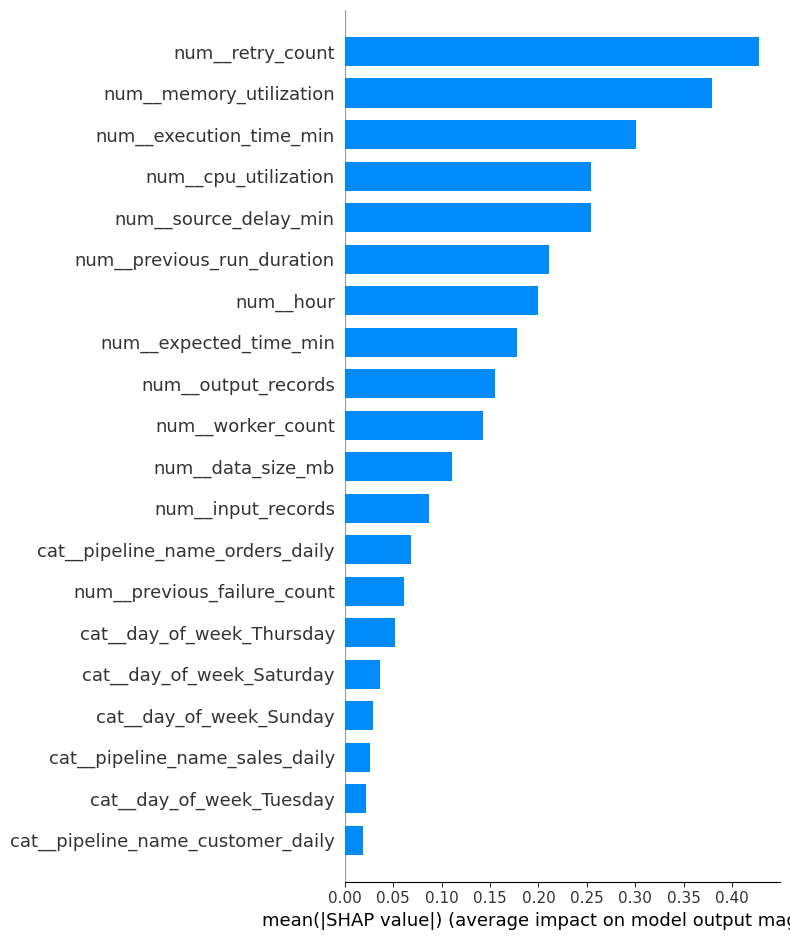

In [43]:
# Global feature importance — which features matter most across all pipeline runs
shap.summary_plot(shap_values, X_test_processed_df, plot_type='bar', show=True)

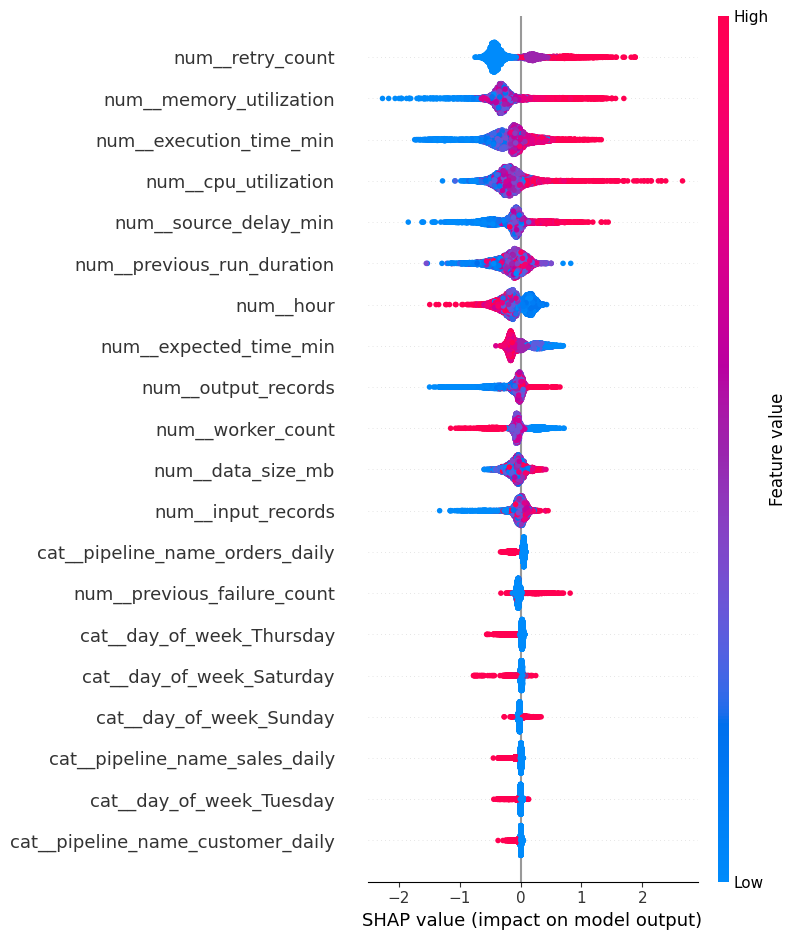

In [44]:
# Global summary — direction + magnitude of each feature's effect
shap.summary_plot(shap_values, X_test_processed_df, show=True)

Row index (within test set): 2615
Predicted failure probability: 97.52%
Actual outcome: Failure


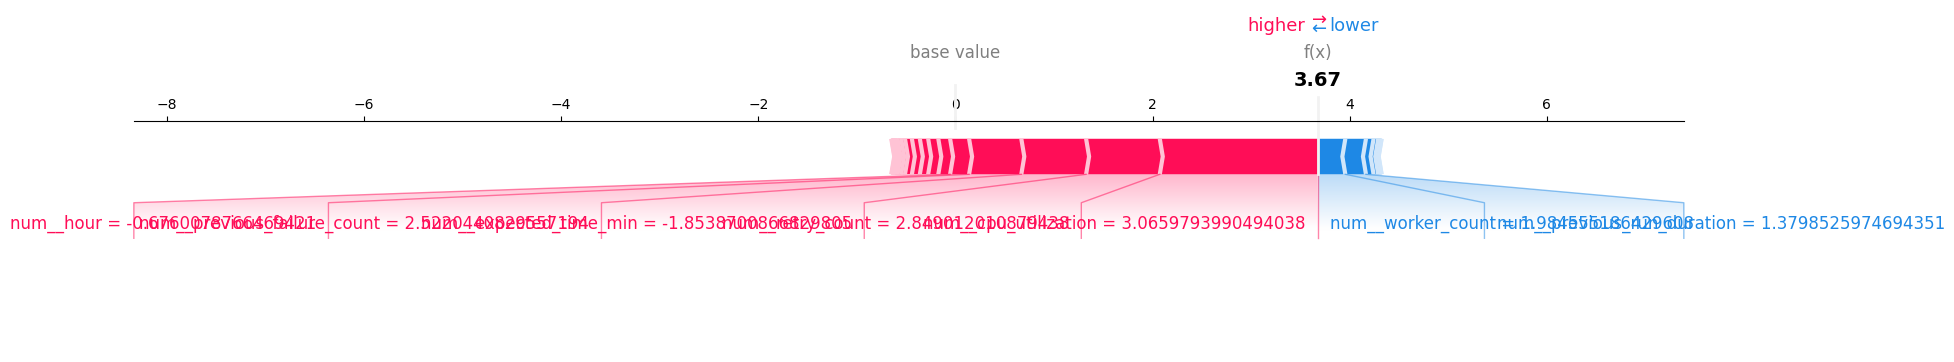

In [45]:
# Local explanation for a single high-risk pipeline run
# Pick the test-set run with the highest predicted failure probability
high_risk_idx = np.argmax(xgb_model.predict_proba(X_test_processed)[:, 1])

print(f"Row index (within test set): {high_risk_idx}")
print(f"Predicted failure probability: {xgb_model.predict_proba(X_test_processed)[high_risk_idx, 1]:.2%}")
print(f"Actual outcome: {'Failure' if y_test.iloc[high_risk_idx] == 1 else 'Success'}")

shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test_processed_df.iloc[high_risk_idx],
    matplotlib=True
)

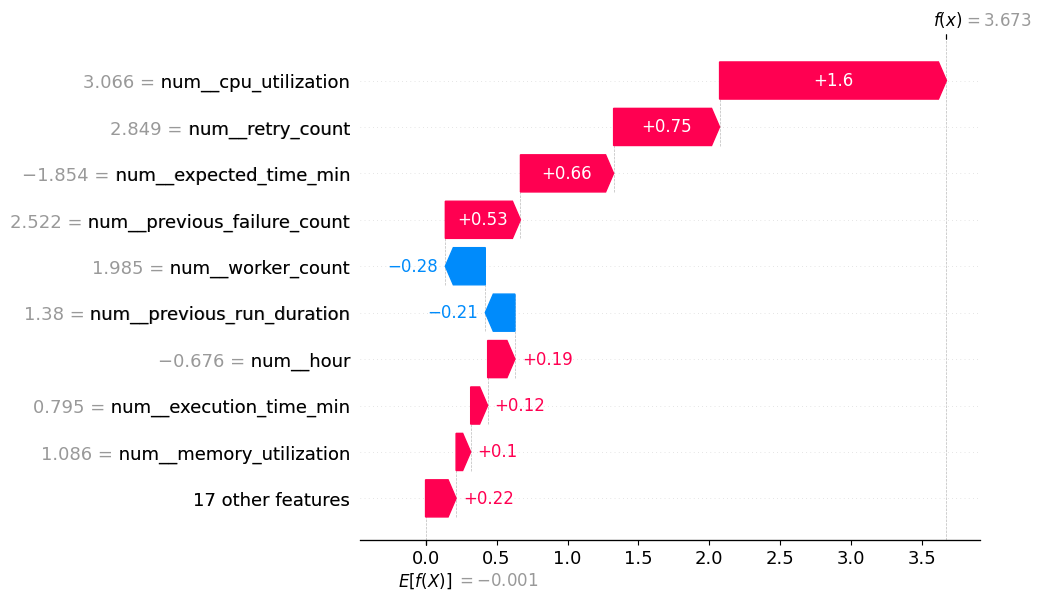

In [46]:
# Waterfall plot — a clearer read of the same single prediction, feature by feature
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_processed_df.iloc[high_risk_idx],
        feature_names=X_test_processed_df.columns.tolist()
    )
)

## Save the Model

Save the trained model, the fitted preprocessor (already saved earlier), and the feature name list — the Streamlit app will need all three to turn a new pipeline run into a prediction.

In [47]:
import joblib

joblib.dump(best_model, '/content/pipeline_failure_model.pkl')
joblib.dump(feature_names, '/content/feature_names.pkl')

print(f"Saved model: {best_model_name}")
print("Files written:")
print("  /content/preprocessor.pkl        (already saved earlier)")
print("  /content/pipeline_failure_model.pkl")
print("  /content/feature_names.pkl")

Saved model: XGBoost
Files written:
  /content/preprocessor.pkl        (already saved earlier)
  /content/pipeline_failure_model.pkl
  /content/feature_names.pkl
